Open the data from DataPart5.csv and model it using an ARMA model,
increasing the model order assisted by the ACF and PACF, until the residuals
look white. When you are reasonably satisfied compute the LDF of the
residuals. Do you find any significant non-linearities? Propose a better
model structure.

Hints Check the n-step residuals versus residuals plot, where n is the sig-
nificant LDF lag, i.e., et versus et−n.

R The script ldf.R is a way to estimate lagged dependent functions.

Matlab The script in ldf.m does an estimation of Lagged Dependent Func-
tions. The script in ldfone.m can be used to see the estimated dependence
function for some lag.

In [26]:
import importlib

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


# Function from the R-script
import utils
importlib.reload(utils)
from utils import local_polynomial_predict, leave_one_out, calculate_ldf, plot_ldf

# Load data

In [27]:
# Download data from csv file
data_path = '../data/'
# Load dataset to numpy
data = pd.read_csv(data_path + 'DataPart5.csv')
np_data = data['x'].to_numpy()

In [28]:
# Print summary statistics of np_data
print("Summary Statistics:")
print(f"Mean: {np.mean(np_data):.4f}")
print(f"Standard Deviation: {np.std(np_data):.4f}")
print(f"Minimum: {np.min(np_data):.4f}")
print(f"Maximum: {np.max(np_data):.4f}")
print(f"First 5 values: {np_data[:5]}")

Summary Statistics:
Mean: 2.2324
Standard Deviation: 2.0929
Minimum: -5.0621
Maximum: 7.9069
First 5 values: [0.         0.         0.04370232 0.24418537 0.22837277]


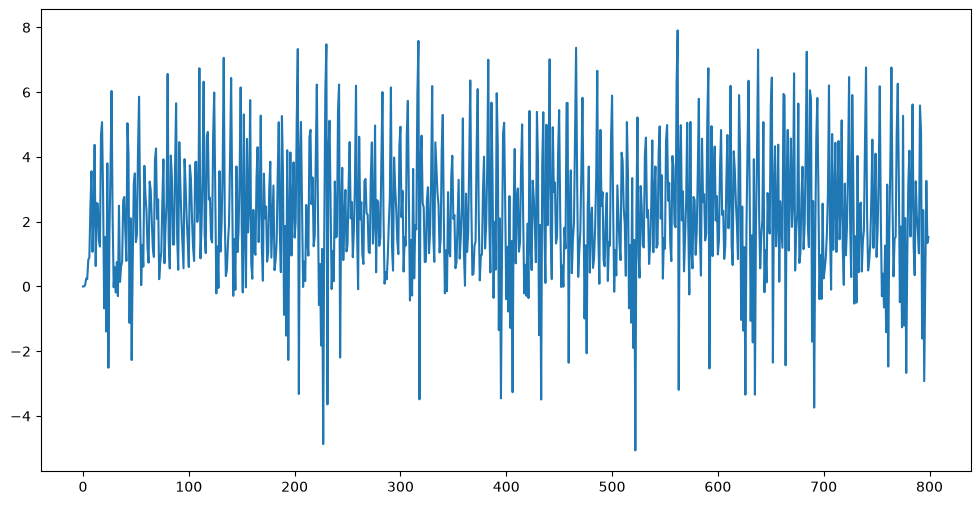

In [29]:
# Plot numpy data
plt.figure(figsize=(12, 6))
plt.plot(np_data)
plt.show()

# ARMA - Remove linear time dependence


ARMA(0,0)
AIC: 3455.98
BIC: 3465.35


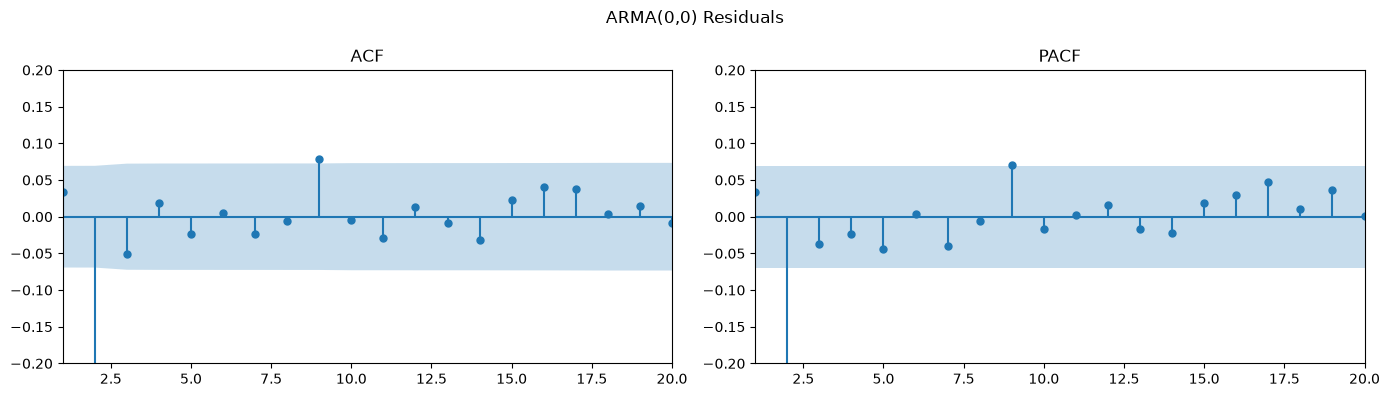


ARMA(1,1)
AIC: 3448.99
BIC: 3467.72


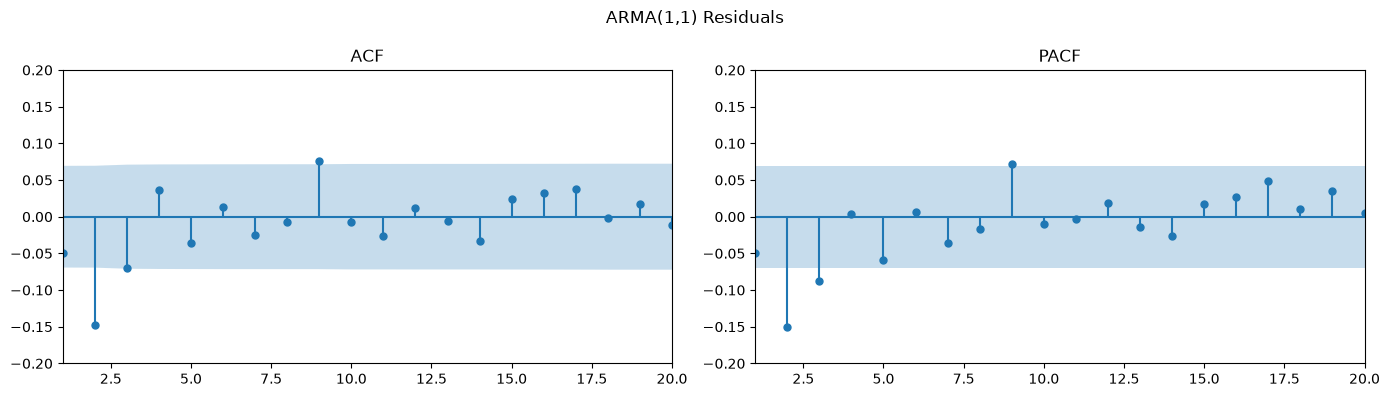


ARMA(2,2)
AIC: 3424.34
BIC: 3452.45


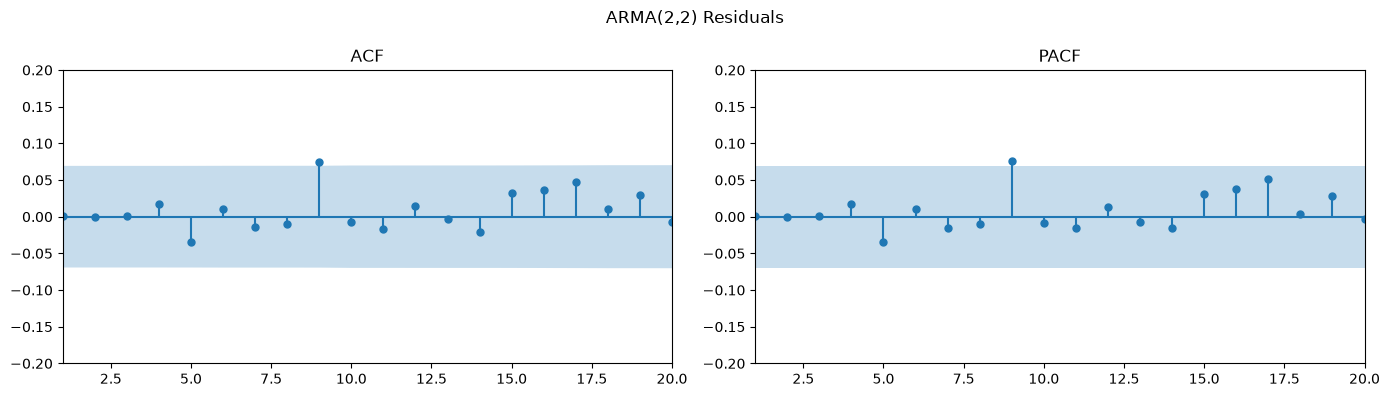

In [30]:
def create_arma_model(data : np.ndarray, 
    p: int, # order of the autoregressive part
    q: int # the order of the moving-average part
):
    model = ARIMA(data, order=(p, 0, q))
    fitted_model = model.fit()
    return fitted_model


def plot_acf_pacf(data : np.ndarray, lags=40, y_limit = 0.2, filename=None, title=None, aic=None, bic=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(data, lags=lags, ax=axes[0])
    plot_pacf(data, lags=lags, ax=axes[1], method='ywm')
    axes[0].set_xlim([1, lags])
    axes[1].set_xlim([1, lags])
    axes[0].set_ylim([-y_limit, y_limit])
    axes[1].set_ylim([-y_limit, y_limit])
    if aic is not None and bic is not None:
        axes[0].set_title(f'ACF (AIC: {aic:.2f})')
        axes[1].set_title(f'PACF (BIC: {bic:.2f})')
    else:
        axes[0].set_title('ACF')
        axes[1].set_title('PACF')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    if filename:
        plt.savefig(f"assets/{filename}")
    plt.show()
    return fig, axes

candidates = [
    (0, 0),
    (1, 1),
    (2, 2),
]

for p, q in candidates:
    model = create_arma_model(np_data, p, q)

    if p == 2 and q == 2:
        chosen_arma = model

    print(f"\nARMA({p},{q})")
    print(f"AIC: {model.aic:.2f}")
    print(f"BIC: {model.bic:.2f}")

    plot_acf_pacf(model.resid, lags=20, y_limit=0.2, filename=f"arma_{p}_{q}_residuals_acf_pacf.png", title=f"ARMA({p},{q}) Residuals")

# LDF

In [ ]:
lags_range = np.arange(1, 9)
lags_max = max(lags_range)
ldf_values, confidence_level = calculate_ldf(
    x = np_data,
    lags = lags_range,
    n_boot=30,
    plot_fits=False,
    random_state=42
)
plot_ldf(
    lags = lags_range,
    ldf_values = ldf_values,
    confidence_level = confidence_level,
    filename = f"ldf_{lags_max}_plot.png"
)


Calculating LDF no. 1 of 8
Calculating LDF no. 2 of 8
Calculating LDF no. 3 of 8
Calculating LDF no. 4 of 8
Calculating LDF no. 5 of 8
Calculating LDF no. 6 of 8
Calculating LDF no. 7 of 8
Calculating LDF no. 8 of 8


# n-step residuals versus residuals plot

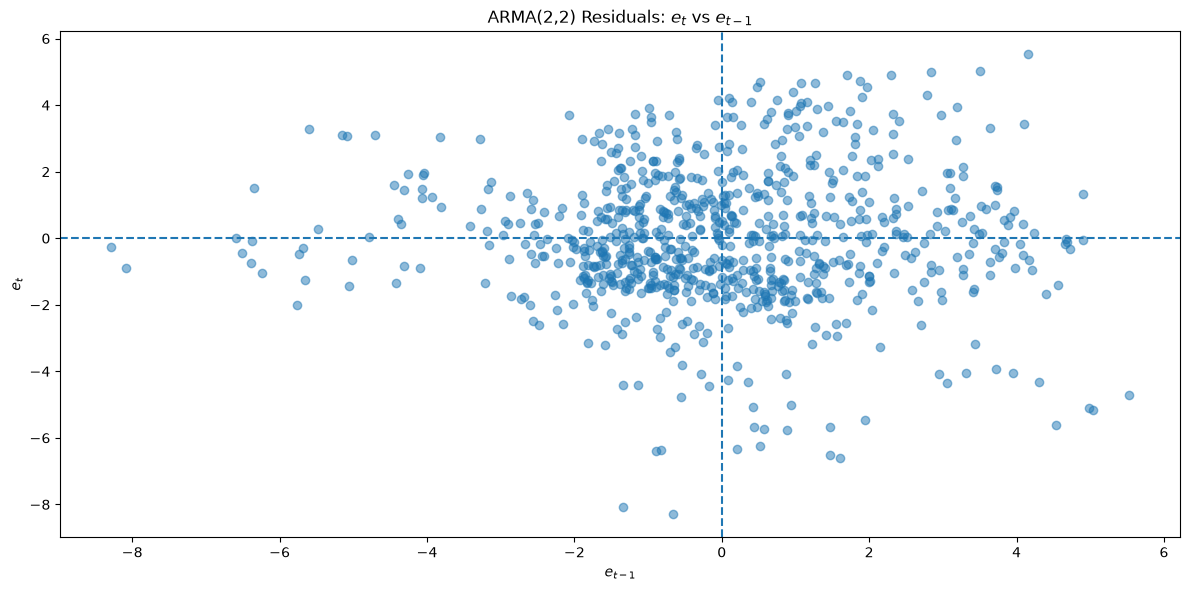

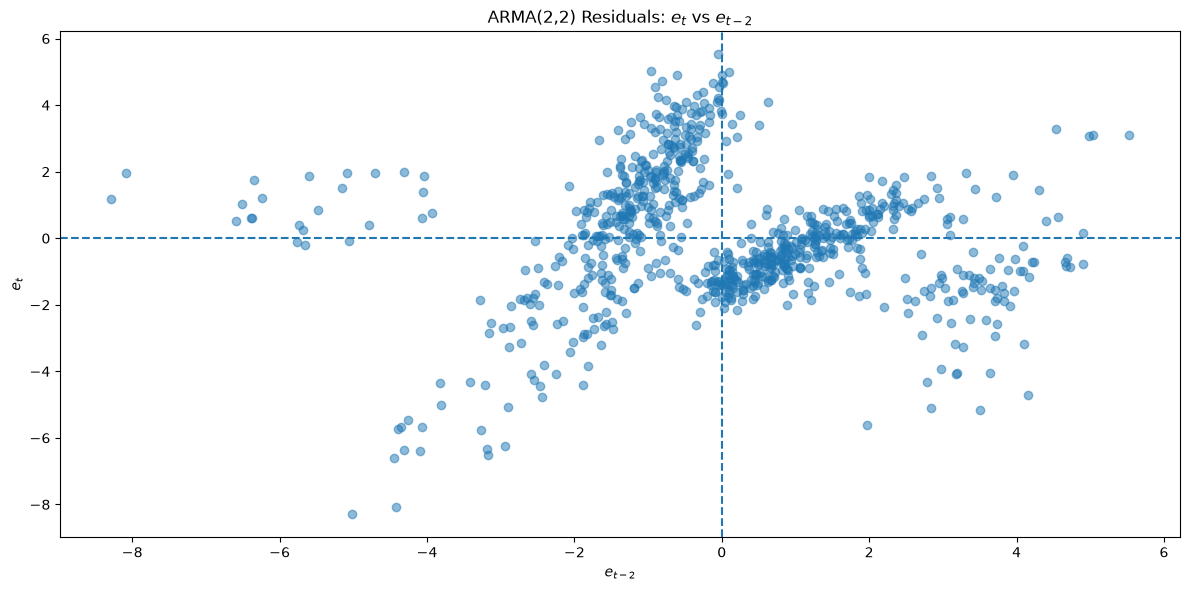

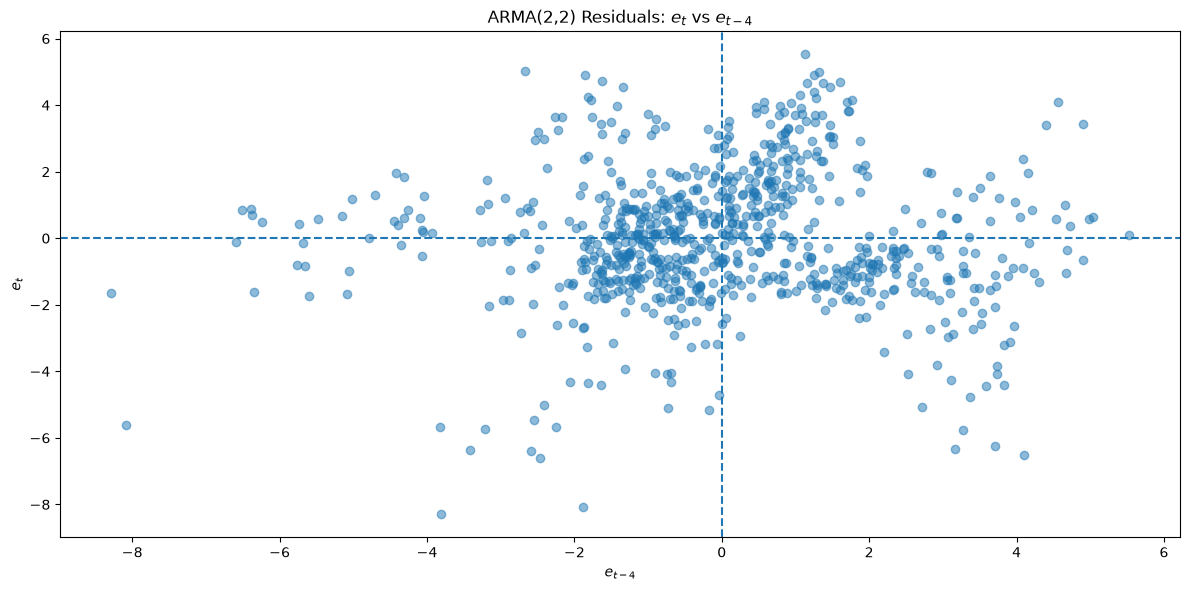

In [ ]:
def plot_n_step_residuals(
    residuals,
    n_steps=1,
    filename=None,
    title=None
):
    residuals = np.asarray(residuals)
    residuals_lagged = residuals[:-n_steps]
    residuals_current = residuals[n_steps:]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(
        residuals_lagged,
        residuals_current,
        alpha=0.5
    )
    ax.axhline(0, linestyle='--')
    ax.axvline(0, linestyle='--')
    ax.set_xlabel(fr"$e_{{t-{n_steps}}}$")
    ax.set_ylabel(r"$e_t$")

    if title:
        ax.set_title(title)
    else:
        ax.set_title(
            fr"Residuals: $e_t$ vs $e_{{t-{n_steps}}}$"
        )

    plt.tight_layout()

    if filename:
        plt.savefig(
            f"assets/{filename}",
            bbox_inches="tight"
        )

    plt.show()



In [ ]:
n = [1, 2, 4]

residuals = chosen_arma.resid
for n_steps in n:
    plot_n_step_residuals(
        residuals=residuals,
        n_steps=n_steps,
        filename=f"arma_2_2_residuals_n_step_{n_steps}.png",
        title=fr"ARMA(2,2) Residuals: $e_t$ vs $e_{{t-{n_steps}}}$"
    )


TypeError: plot_n_step_residuals() got an unexpected keyword argument 'cluster'

# Exploartion of new model approch

### Every second step - original data

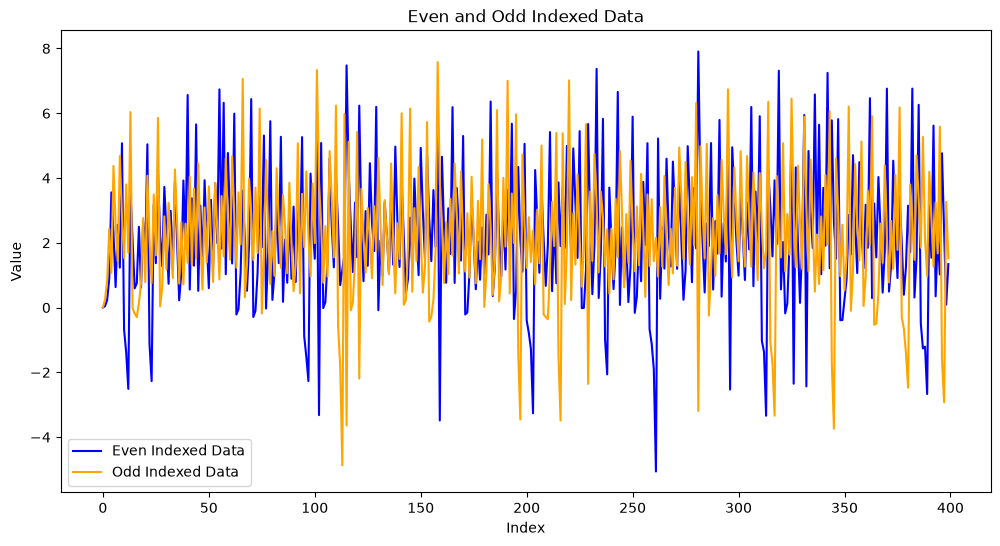

In [ ]:
np_data_even = np_data[::2]
np_data_odd = np_data[1::2]

# Plot the even and odd indexed data
plt.figure(figsize=(12, 6))
plt.plot(np_data_even, label='Even Indexed Data', color='blue')
plt.plot(np_data_odd, label='Odd Indexed Data', color='orange')
plt.title('Even and Odd Indexed Data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.show()

### Every second step - ARMA(2,2)

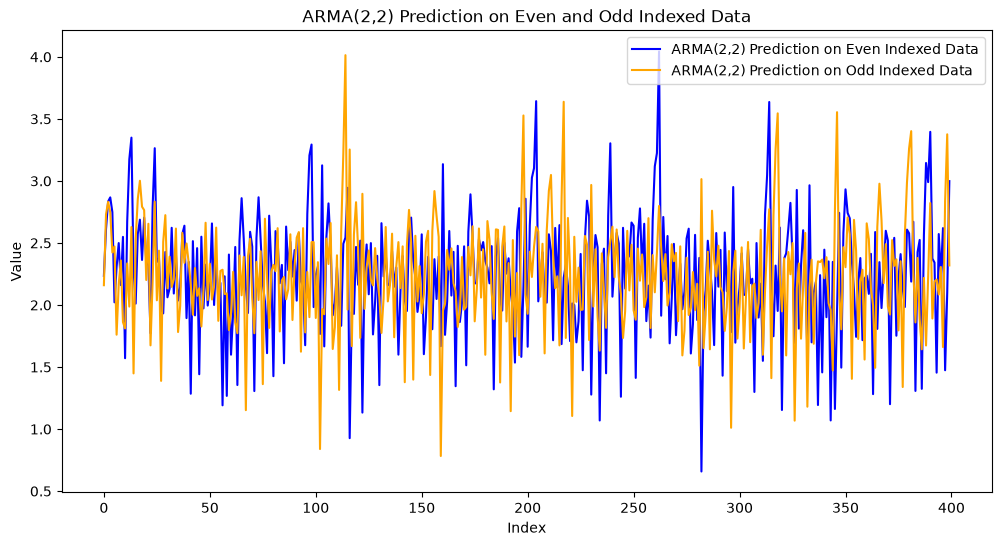

In [ ]:
# Fit ARMA(2,2) model to even indexed data
# arma_chosen

arma_pred = chosen_arma.predict(start=0, end=len(np_data)-1)
arma_pred_even = arma_pred[::2]
arma_pred_odd = arma_pred[1::2]

# Plot these
plt.figure(figsize=(12, 6))
plt.plot(arma_pred_even, label='ARMA(2,2) Prediction on Even Indexed Data', color='blue')
plt.plot(arma_pred_odd, label='ARMA(2,2) Prediction on Odd Indexed Data', color='orange')
plt.title('ARMA(2,2) Prediction on Even and Odd Indexed Data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.show()
